In [1]:
load_ext jupyter_black

In [2]:
import matplotlib.pyplot as plt
import os
import pickle
import pandas as pd
import seaborn as sns

In [3]:
demographics = {
    "personamem": ["age", "gender", "ethnicity"],
    "cad_en": [
        "annotator_age",
        "annotator_education_level",
        "annotator_gender",
        "annotator_political",
        "annotator_ethnicity",
    ],
    "prism": [
        "age",
        "birth_region",
        "education",
        "employment_status",
        "english_proficiency",
        "ethnicity",
        "gender",
        "lm_familiarity",
        "marital_status",
        "religion",
        "reside_region",
    ],
}

models = ["Llama-3.1-8B-Instruct", "gemma-3-12b-it"]

In [4]:
data = {
    "model": [],
    "dataset": [],
    "demographic": [],
    "balanced": [],
    "layer": [],
    "cv": [],
    "f1": [],
    "majority f1": [],
    "random f1": [],
    "majority aso": [],
    "random aso": [],
    "majority aso_better": [],
    "random aso_better": [],
}

for model in models:
    for dataset in demographics:
        for demographic in demographics[dataset]:
            for balanced in [True, False]:
                if os.path.isfile(
                    f"probing_results/{model}_{dataset}_{demographic}{'_balanced' if balanced else ''}_scores.pkl"
                ):
                    with open(
                        f"probing_results/{model}_{dataset}_{demographic}{'_balanced' if balanced else ''}_scores.pkl",
                        "rb",
                    ) as infile:
                        results = pickle.load(infile)
                    for layer in results:
                        for cv in range(5):
                            data["model"].append(model)
                            data["dataset"].append(dataset)
                            data["demographic"].append(demographic)
                            data["balanced"].append(balanced)
                            data["layer"].append(layer)
                            data["cv"].append(cv)
                            for score in ["f1", "majority f1", "random f1"]:
                                data[score].append(results[layer][score][cv])
                            for aso_score in ["majority aso", "random aso"]:
                                data[aso_score].append(results[layer][aso_score])
                                data[aso_score + "_better"].append(
                                    results[layer][aso_score] < 0.5
                                )

df = pd.DataFrame(data)

In [5]:
df

,model,dataset,demographic,balanced,layer,cv,f1,majority f1,random f1,majority aso,random aso,majority aso_better,random aso_better
0,Llama-3.1-8B-Instruct,personamem,age,True,0,0,0.312500,0.352941,0.487691,0.997996,0.997853,False,False
1,Llama-3.1-8B-Instruct,personamem,age,True,0,1,0.324232,0.342193,0.533641,0.997996,0.997853,False,False
2,Llama-3.1-8B-Instruct,personamem,age,True,0,2,0.324232,0.342193,0.499374,0.997996,0.997853,False,False
3,Llama-3.1-8B-Instruct,personamem,age,True,0,3,0.331081,0.335570,0.620970,0.997996,0.997853,False,False
4,Llama-3.1-8B-Instruct,personamem,age,True,0,4,0.317241,0.348684,0.525059,0.997996,0.997853,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12155,gemma-3-12b-it,prism,reside_region,False,31,0,0.240823,0.117232,0.164516,0.000000,0.000000,True,True
12156,gemma-3-12b-it,prism,reside_region,False,31,1,0.240354,0.115726,0.163184,0.000000,0.000000,True,True
12157,gemma-3-12b-it,prism,reside_region,False,31,2,0.245593,0.114000,0.176203,0.000000,0.000000,True,True
12158,gemma-3-12b-it,prism,reside_region,False,31,3,0.226017,0.116531,0.162070,0.000000,0.000000,True,True


In [6]:
def line_plot(df, ax, legend, df2s=[]):
    plt.rcParams.update({"font.size": 22})
    sns.lineplot(
        df,
        x="layer",
        y="f1",
        ax=ax,
        legend=legend,
        label="Probe",
    )
    for df2 in df2s:
        item = df2["item"].unique()[0]
        sns.lineplot(
            df2,
            x="layer",
            y="f1",
            ax=ax,
            legend=legend,
            label=f"Probe - {item}",
        )
    sns.lineplot(
        df,
        x="layer",
        y="majority f1",
        ax=ax,
        legend=legend,
        label="Majority",
    )
    sns.lineplot(
        df,
        x="layer",
        y="random f1",
        ax=ax,
        legend=legend,
        label="Random",
    )
    if legend:
        if len(df2s) > 0:
            ax.legend(loc="best")
        else:
            ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

    if len(df2s) > 0:
        for df2 in df2s:
            for layer in df2["layer"].unique():
                better = (
                    aso(
                        df.loc[df["layer"] == layer, "f1"],
                        df2.loc[df2["layer"] == layer, "f1"],
                        seed=42,
                    )
                    < 0.5
                )
                ax.scatter(
                    layer,
                    df2.loc[(df2["layer"] == layer)]["f1"].mean(),
                    marker="o" if better else "x",
                    color="blue" if better else "red",
                )

    else:
        better_than_baseline = (
            df.groupby("layer")[["majority aso_better", "random aso_better"]]
            .min()
            .min(axis=1)
        )

        m = ["o" if x else "x" for x in better_than_baseline]
        c = ["blue" if x else "red" for x in better_than_baseline]

        for layer in df["layer"].unique():
            ax.scatter(
                layer,
                df.loc[(df["layer"] == layer)]["f1"].mean(),
                marker=m[layer],
                color=c[layer],
            )
    ax.set_ylabel("Macro F1")

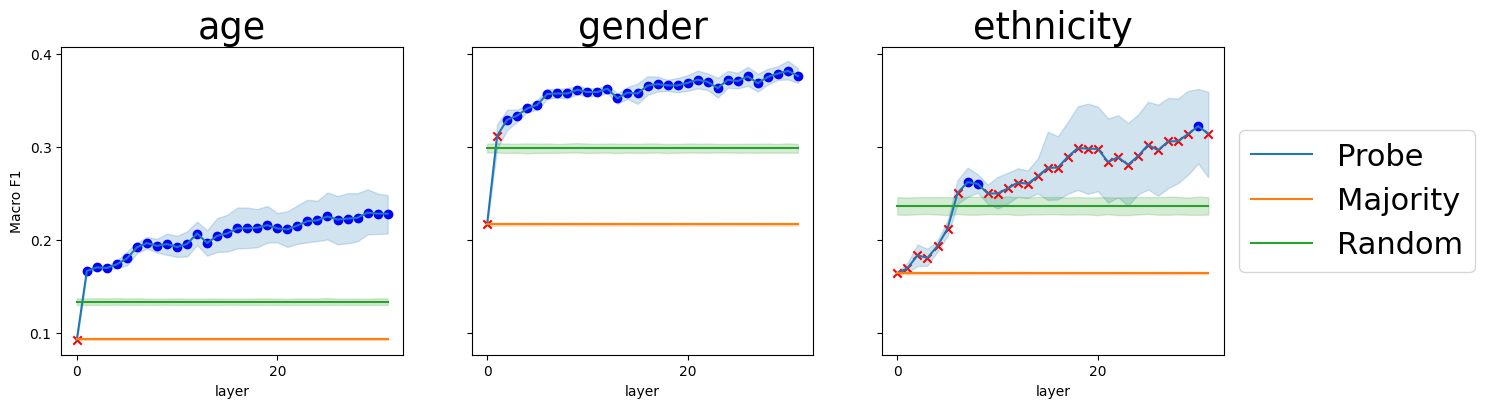

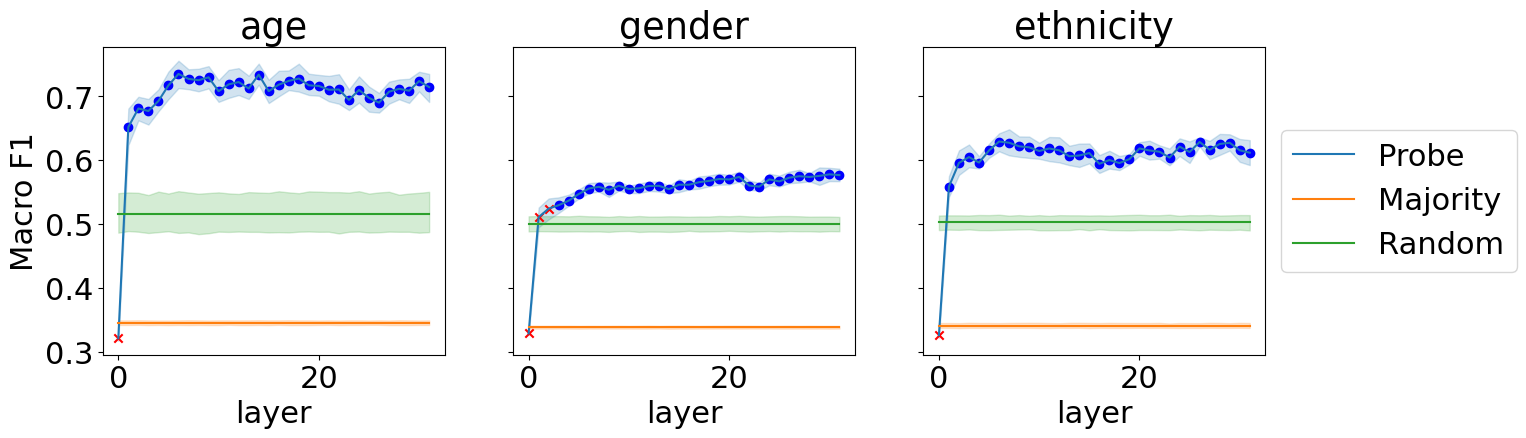

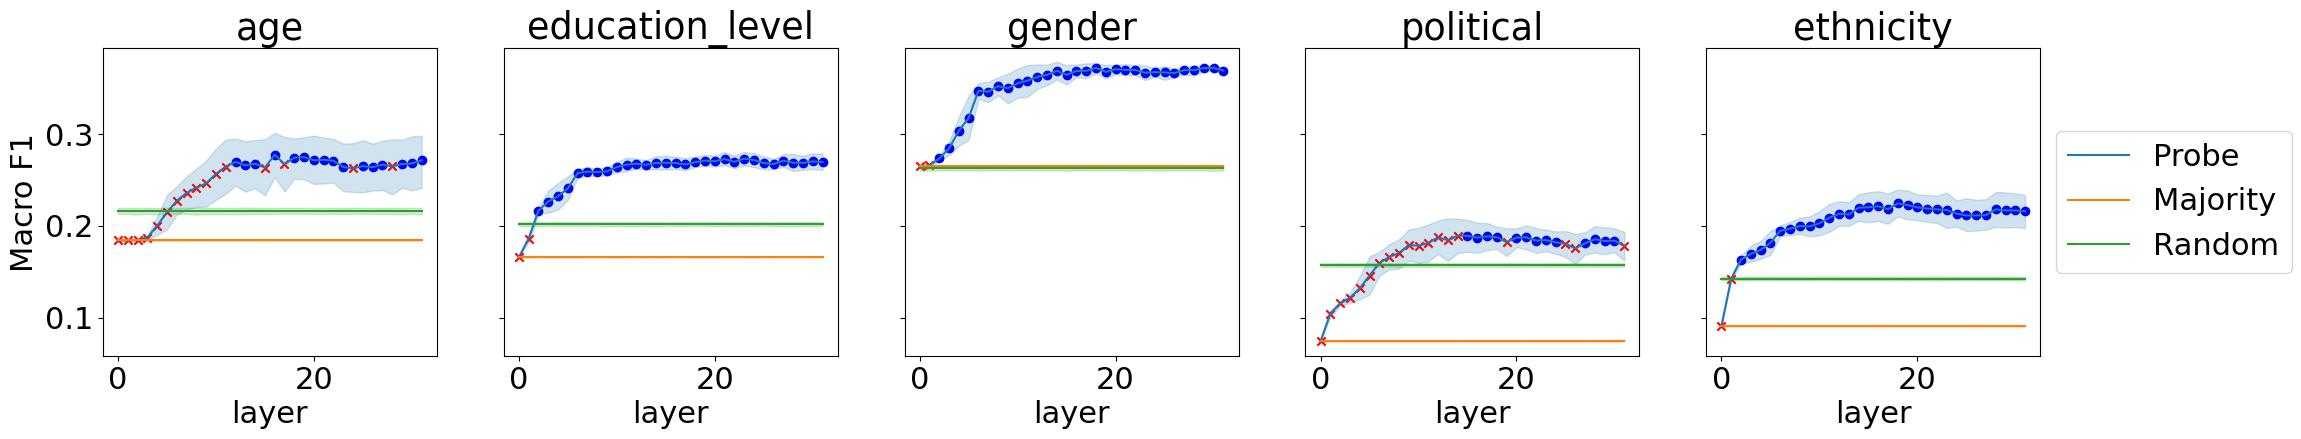

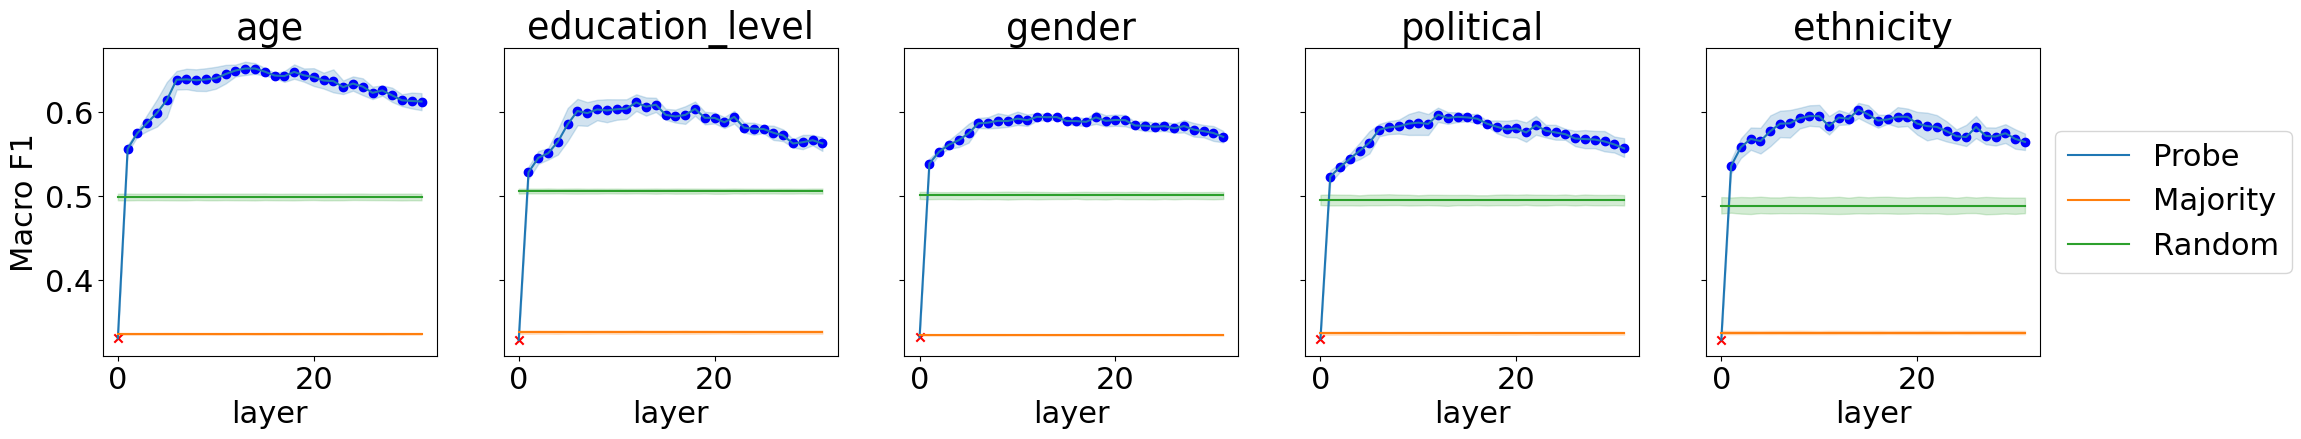

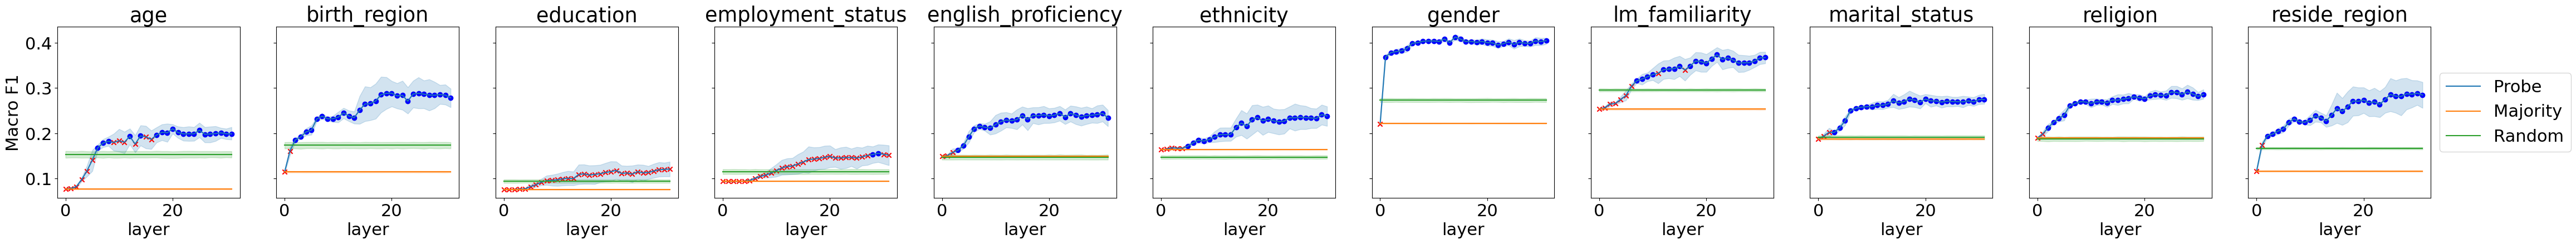

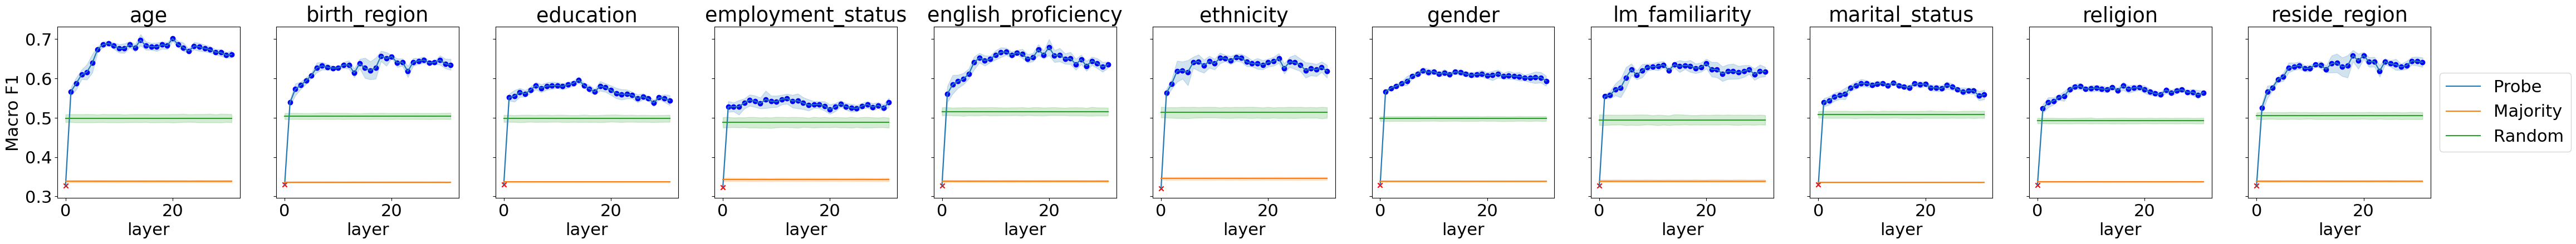

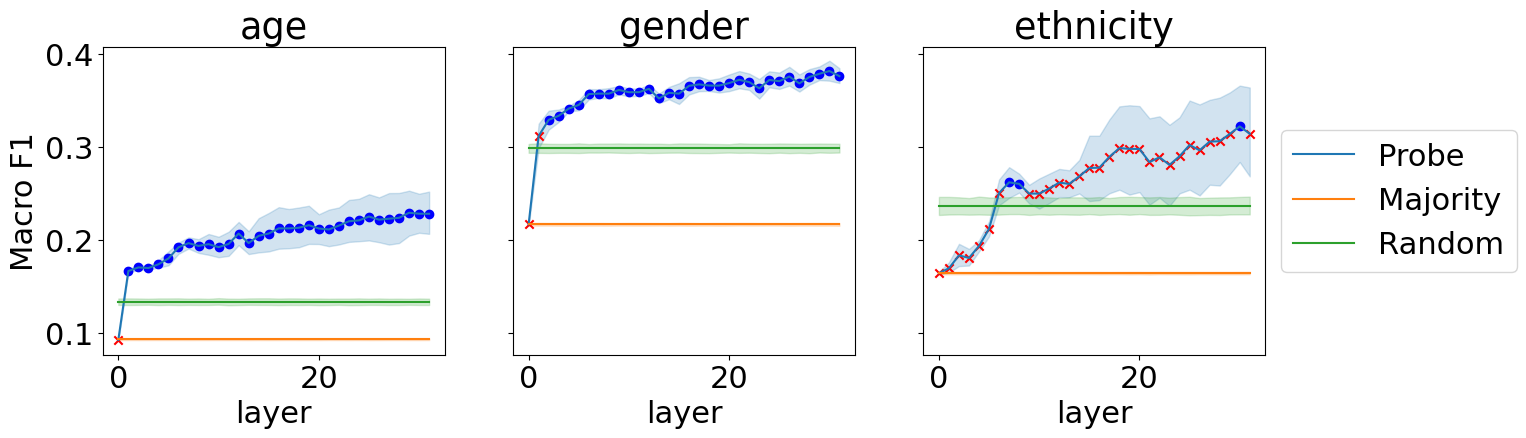

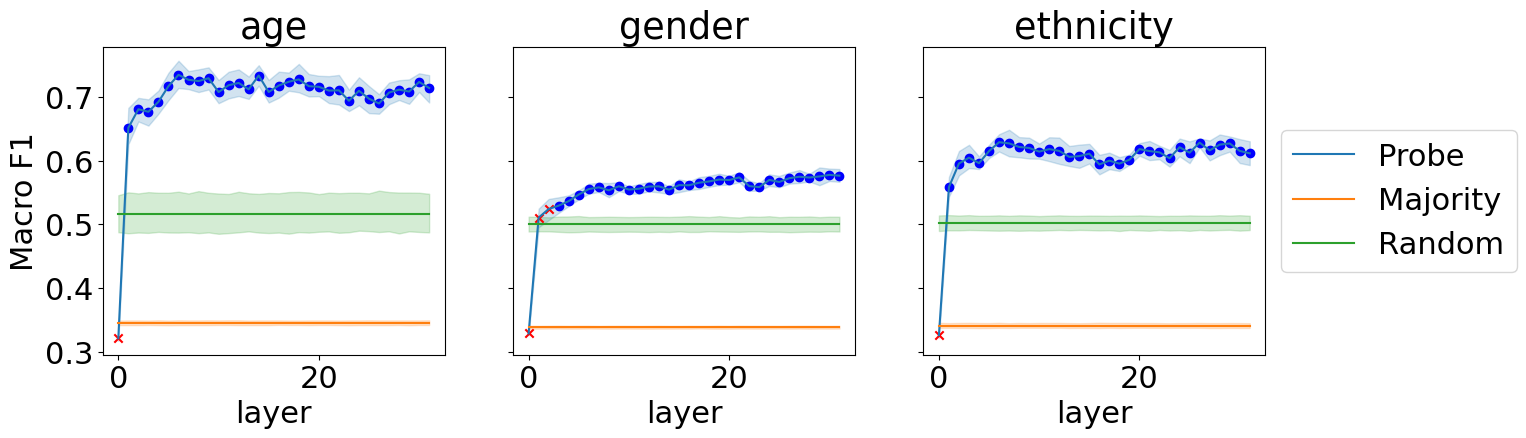

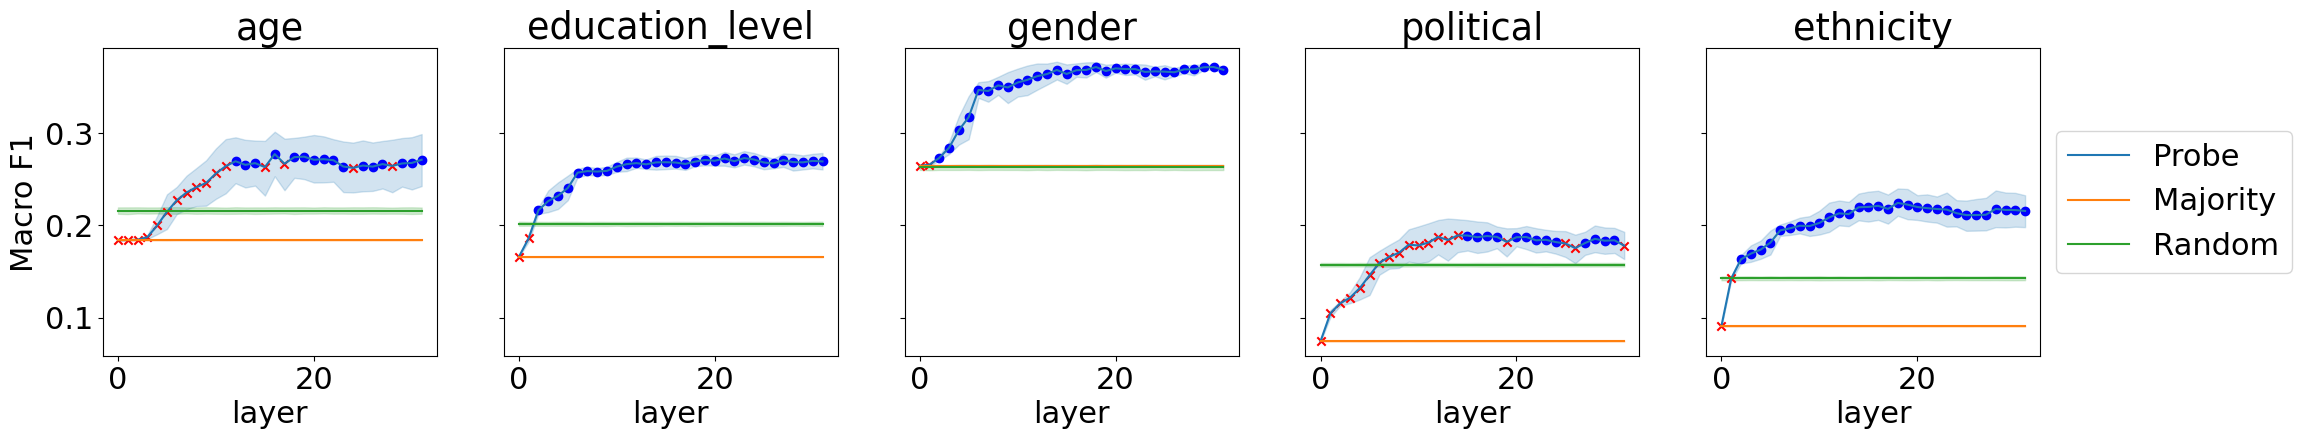

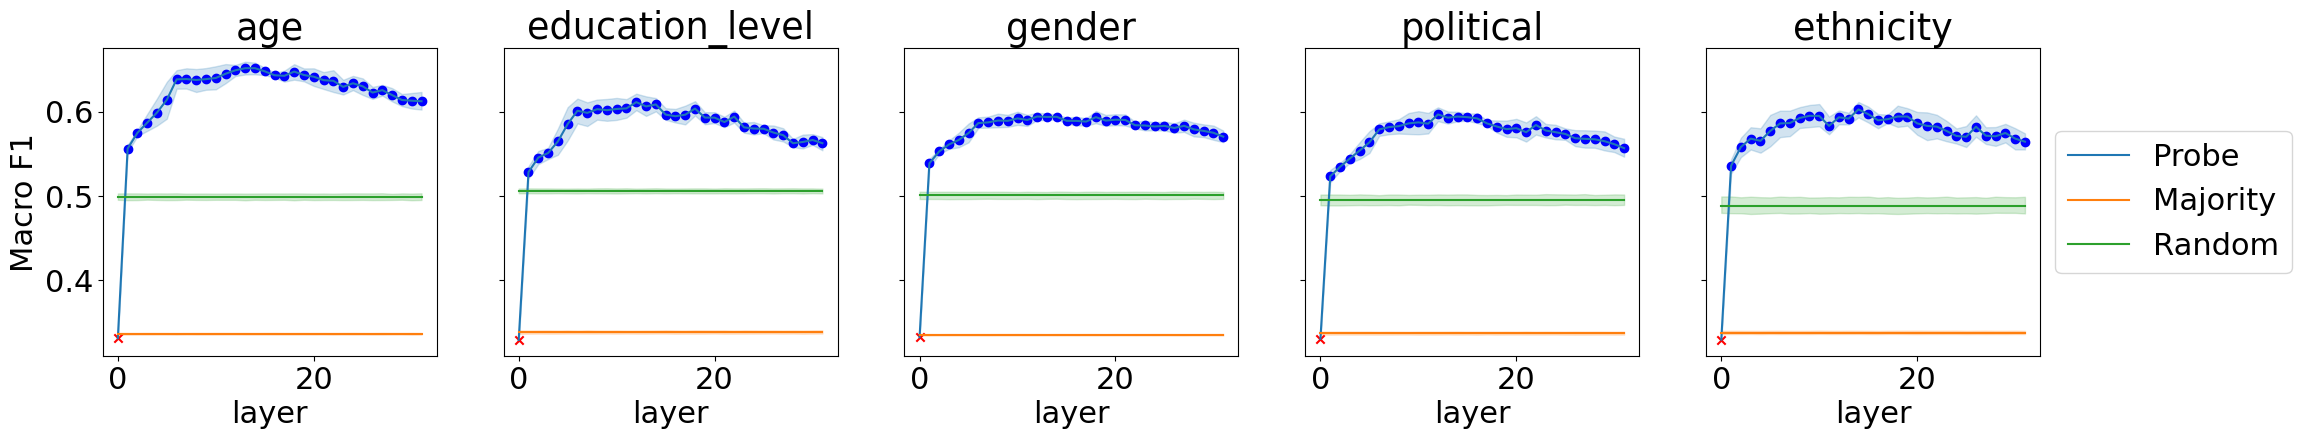

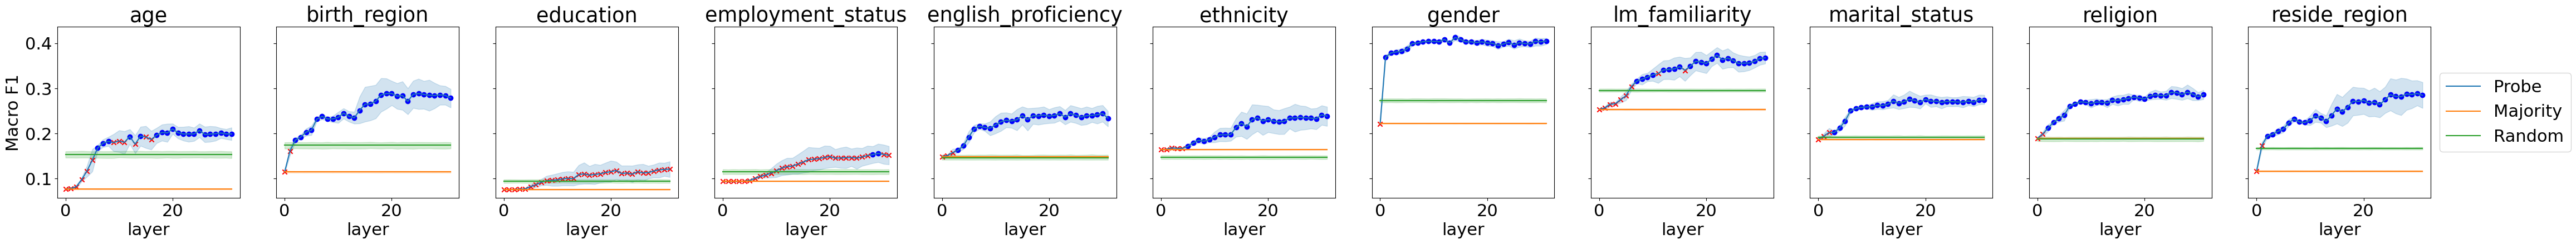

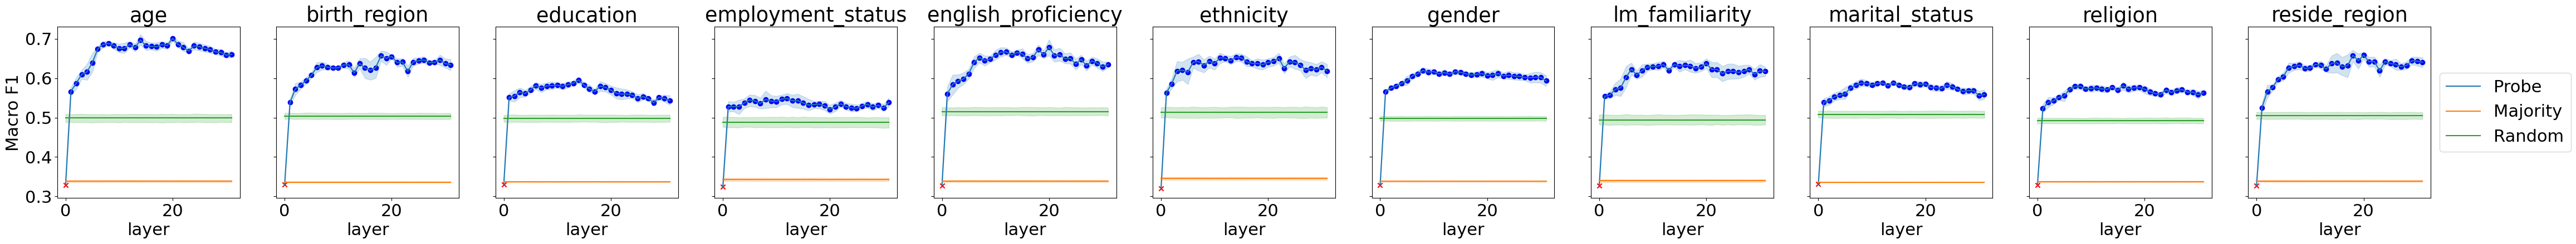

In [7]:
for model in models:
    for dataset in demographics:
        fig, axes = plt.subplots(
            1,
            len(demographics[dataset]),
            figsize=(5 * len(demographics[dataset]), 4),
            sharey=True,
        )
        for d, demographic in enumerate(demographics[dataset]):
            if len(demographics[dataset]) > 1:
                ax = axes[d]
            else:
                ax = axes
            line_plot(
                df.loc[
                    (df["dataset"] == dataset)
                    & (df["demographic"] == demographic)
                    & (df["balanced"] == False)
                ],
                ax,
                legend=d == len(demographics[dataset]) - 1,
            )
            ax.set_title(demographic.split("annotator_")[-1])
        plt.savefig(
            f"probing_figures/{model}_{dataset}_notbalanced.pdf", bbox_inches="tight"
        )
        plt.show()
        fig2, axes = plt.subplots(
            1,
            len(demographics[dataset]),
            figsize=(5 * len(demographics[dataset]), 4),
            sharey=True,
        )
        for d, demographic in enumerate(demographics[dataset]):
            if len(demographics[dataset]) > 1:
                ax = axes[d]
            else:
                ax = axes
            line_plot(
                df.loc[
                    (df["dataset"] == dataset)
                    & (df["demographic"] == demographic)
                    & (df["balanced"] == True)
                ],
                ax,
                legend=d == len(demographics[dataset]) - 1,
            )
            ax.set_title(demographic.split("annotator_")[-1])
        plt.savefig(
            f"probing_figures/{model}_{dataset}_balanced.pdf",
            bbox_inches="tight",
        )
        plt.show()